# Estimation de la Densité de Trafic Urbain par Réseau de Neurones (CSRNet)

**TP de Vision par Ordinateur — INF4238**

**Master 1 Science de Données — Département d'Informatique**

**Année académique 2025/2026**

---

Ce notebook implémente un modèle d'intelligence artificielle basé sur l'architecture **CSRNet** (Dilated Convolutional Neural Networks) pour estimer la densité et compter le nombre de véhicules dans des scènes de trafic routier congestionné.

## Présentation du Dataset

### TRANCOS

Le dataset utilisé pour ce projet est **TRANCOS** (TRAffic CONgestion Sequences),
un jeu de données de référence pour l'estimation de densité de véhicules par
comptage, publié initialement par Oñoro-Rubio & López-Sastre (ECCV 2016).

Il contient **1244 images** issues de caméras de surveillance routières fixes
en Espagne, réparties en deux splits :
- **train_data** : 1031 images
- **test_data** : 213 images

Chaque image est accompagnée de :
- une annotation par points (`txt/`) indiquant la position de chaque véhicule,
- un masque binaire de région d'intérêt (`ground-truth/*.mat`, clé `BW`) délimitant
  la zone de comptage valide,
- une visualisation de contrôle des points superposés (`dots/`).

### Limite contextuelle importante

Conformément aux objectifs pédagogiques de ce TP, qui invitent à ancrer le
projet dans le **contexte camerounais/africain**, nous avons recherché un
dataset équivalent de comptage de véhicules par densité (avec annotations par
points et masque ROI) basé sur des scènes routières africaines.

**Aucun dataset de ce type, suffisamment documenté et exploitable pour
l'entraînement d'un modèle de type CSRNet, n'a été identifié à ce jour.** Les
datasets de trafic disponibles pour le contexte africain (lorsqu'ils existent)
sont majoritairement orientés vers la classification d'image (ex. Traffic-Net)
ou la détection d'objets, et ne fournissent pas les annotations par points
nécessaires à la génération de cartes de densité.

Nous avons donc choisi d'entraîner et d'évaluer notre modèle sur TRANCOS, dataset
de référence dans la littérature scientifique sur ce sujet, ce qui nous permet
de comparer rigoureusement nos résultats à l'état de l'art existant. Nous
discutons dans la partie "Analyse critique" de ce notebook les implications de
ce choix — notamment l'écart de domaine (perspective caméra, densité et types
de véhicules) entre le contexte espagnol de TRANCOS et un déploiement réel en
contexte camerounais, ainsi que les pistes possibles pour combler ce manque
(collecte et annotation locale via CVAT, comme évoqué dans l'énoncé du projet).

---

## Étape 0 : Exploration et compréhension des données

Avant toute implémentation, nous inspectons la structure du dataset TRANCOS pour
valider la cohérence des fichiers et comprendre le format des annotations.

Le dataset est organisé en deux splits (`train_data` et `test_data`), chacun
contenant 4 sous-dossiers : `images/` (.jpg), `txt/` (.txt, points annotés),
`ground-truth/` (.mat, masque ROI) et `dots/` (.png, visualisation des points).

**Convention de nommage** : un même échantillon partage un ID de base
(ex. `image-1-000001`), mais chaque dossier ajoute un suffixe différent
(`.jpg`, `.txt`, `mask.mat`, `dots.png`) — sans underscore. Cette particularité
a été identifiée par inspection directe des fichiers.




## 1. Initialisation et Configuration des Chemins
Nous commençons par importer les bibliothèques fondamentales pour la manipulation des fichiers (`pathlib`), le traitement d'images (`PIL`), le calcul numérique (`numpy`) et le chargement des annotations au format Matlab (`scipy.io`). Nous définissons également l'arborescence des dossiers du dataset **TRANCOS**.

In [58]:
from pathlib import Path
from scipy.io import loadmat
from PIL import Image
import numpy as np

BASE_DIR = Path("TRANCOS")  
TRAIN_DIR = BASE_DIR / "train_data"
TEST_DIR = BASE_DIR / "test_data"


### Extraction des Identifiants Uniques
Pour associer correctement chaque image à ses fichiers d'annotations correspondants (masques de région d'intérêt, positions des véhicules), nous développons une fonction utilitaire permettant d'extraire les identifiants (`IDs`) uniques en nettoyant les suffixes des noms de fichiers.

In [2]:
def get_ids(folder, suffix):
    """Extrait l'ID de base en retirant le suffixe donné.
    Ex: 'image-1-000001mask.mat' avec suffix='mask.mat' -> 'image-1-000001'
    """
    if not folder.exists():
        return set()
    ids = set()
    for p in folder.iterdir():
        name = p.name
        if name.endswith(suffix):
            ids.add(name[: -len(suffix)])
    return ids

### Vérification de cohérence entre les 4 dossiers

Nous vérifions que chaque ID d'échantillon possède bien ses 4 fichiers
correspondants (image, points, masque ROI, visualisation), afin de détecter
tout fichier orphelin avant de poursuivre.

In [3]:
images_dir = TRAIN_DIR / "images"
txt_dir = TRAIN_DIR / "txt"
gt_dir = TRAIN_DIR / "ground-truth"
dots_dir = TRAIN_DIR / "dots"

ids_images = get_ids(images_dir, ".jpg")
ids_txt = get_ids(txt_dir, ".txt")
ids_gt = get_ids(gt_dir, "mask.mat")
ids_dots = get_ids(dots_dir, "dots.png")

print(f"images/: {len(ids_images)} | txt/: {len(ids_txt)} | ground-truth/: {len(ids_gt)} | dots/: {len(ids_dots)}")

common_ids = sorted(ids_images & ids_txt & ids_gt & ids_dots)
all_ids = ids_images | ids_txt | ids_gt | ids_dots

print(f"IDs communs aux 4 dossiers : {len(common_ids)} / {len(all_ids)}")

for name, ids_set in [("images", ids_images), ("txt", ids_txt), ("ground-truth", ids_gt), ("dots", ids_dots)]:
    missing = all_ids - ids_set
    if missing:
        print(f"Manquant dans {name}/ : {len(missing)} -> exemples: {sorted(missing)[:5]}")

images/: 1031 | txt/: 1031 | ground-truth/: 1031 | dots/: 1031
IDs communs aux 4 dossiers : 1031 / 1031


### Inspection de la structure du fichier `.mat` (masque ROI)

Le fichier `ground-truth/*.mat` ne contient qu'une seule clé, `BW` : un masque
binaire (0/1) de la taille de l'image, délimitant la région d'intérêt (ROI) —
c'est-à-dire les zones de la scène où le comptage de véhicules est valide.

**Point méthodologique important** : ce dossier ne contient pas la vérité-terrain
du comptage (les positions des véhicules), contrairement à ce que son nom suggère.
Les positions des véhicules sont uniquement disponibles dans `txt/`.

In [4]:
sample_id = common_ids[0]
mat_path = gt_dir / f"{sample_id}mask.mat"
mat_data = loadmat(str(mat_path))

bw = mat_data["BW"]
print(f"BW shape: {bw.shape}, dtype: {bw.dtype}, valeurs uniques: {np.unique(bw)}")
print(f"Proportion de l'image dans la ROI: {bw.sum() / bw.size:.2%}")

BW shape: (480, 640), dtype: uint8, valeurs uniques: [0 1]
Proportion de l'image dans la ROI: 42.76%


### Statistiques descriptives (comptage et résolution)

Nous calculons, pour chaque split, la distribution du nombre de véhicules par
image (min/max/moyenne/médiane) à partir des fichiers `.txt`, ainsi que les
résolutions d'image rencontrées — utile pour anticiper les besoins de
redimensionnement à l'étape de prétraitement.

In [5]:
counts = []
resolutions = set()

for sample_id in common_ids:
    with open(txt_dir / f"{sample_id}.txt") as f:
        n_points = len([l for l in f if l.strip()])
    counts.append(n_points)

    with Image.open(images_dir / f"{sample_id}.jpg") as img:
        resolutions.add(img.size)

counts = np.array(counts)
print(f"Comptage -> min: {counts.min()}, max: {counts.max()}, moyenne: {counts.mean():.2f}, médiane: {np.median(counts):.1f}, std: {counts.std():.2f}")
print(f"Résolutions rencontrées : {resolutions}")

Comptage -> min: 9, max: 107, moyenne: 38.17, médiane: 36.0, std: 15.76
Résolutions rencontrées : {(640, 480)}


### Visualisation de contrôle

Superposition des points annotés sur l'image originale, comparée visuellement
au fichier `dots/*.png` fourni, afin de confirmer que les coordonnées (x, y)
sont correctement interprétées.

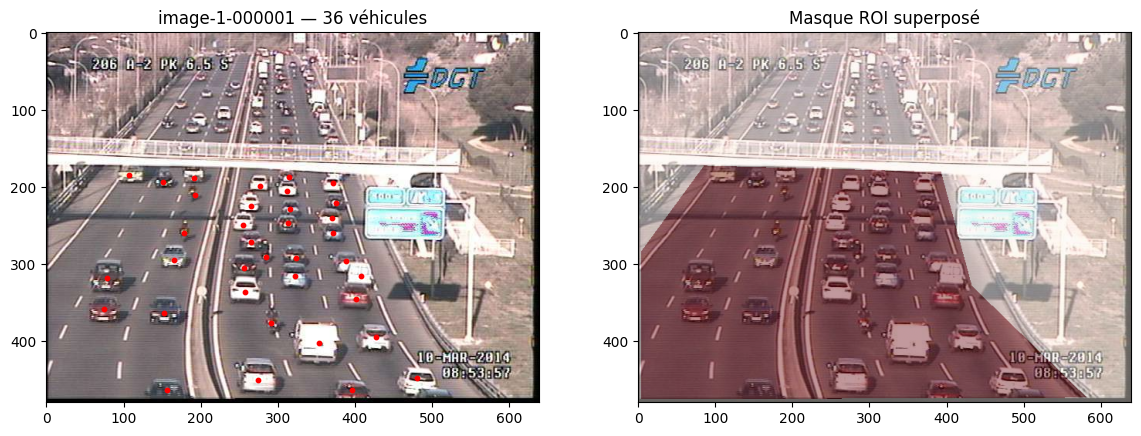

In [6]:
import matplotlib.pyplot as plt

sample_id = common_ids[0]
img = Image.open(images_dir / f"{sample_id}.jpg")
bw = loadmat(str(gt_dir / f"{sample_id}mask.mat"))["BW"]

with open(txt_dir / f"{sample_id}.txt") as f:
    points = [tuple(map(float, l.split())) for l in f if l.strip()]
xs, ys = zip(*points)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img)
axes[0].scatter(xs, ys, c='red', s=10)
axes[0].set_title(f"{sample_id} — {len(points)} véhicules")

axes[1].imshow(img)
axes[1].imshow(bw, alpha=0.4, cmap='Reds')
axes[1].set_title("Masque ROI superposé")
plt.show()

## Étape 1 : Génération des cartes de densité (ground truth)

CSRNet ne prédit pas des points discrets mais une **carte de densité continue**.
Cette carte n'existe dans aucun fichier fourni par TRANCOS : elle doit être
générée à partir des points annotés (`txt/`), en convoluant une carte binaire
avec un noyau gaussien.

Un signal binaire sparse (un seul pixel actif par véhicule) serait inexploitable
pour l'apprentissage par descente de gradient : la cible serait presque
entièrement nulle, et toute petite erreur de localisation produirait une erreur
disproportionnée. La carte de densité résout ce problème en étalant chaque point
sur un voisinage continu, tout en préservant la propriété fondamentale que la
somme totale de la carte égale le nombre de véhicules annotés.

In [7]:
import numpy as np
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from scipy.spatial import KDTree
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

In [8]:
def load_points(txt_path):
    """Lit les points annotés depuis le fichier .txt -> liste de (x, y)."""
    with open(txt_path) as f:
        points = [tuple(map(float, l.split())) for l in f if l.strip()]
    return points


def points_to_binary_map(points, shape):
    """Crée une carte binaire (H, W) avec un 1 à chaque position de point."""
    h, w = shape
    binary_map = np.zeros((h, w), dtype=np.float32)
    for x, y in points:
        xi, yi = int(round(x)), int(round(y))
        xi = min(max(xi, 0), w - 1)
        yi = min(max(yi, 0), h - 1)
        binary_map[yi, xi] += 1  # += pour gérer le cas (rare) de 2 points au même pixel
    return binary_map

In [9]:
def add_gaussian_normalized(density_map, x, y, sigma):
    """Ajoute un gaussien centré sur (x,y), renormalisé pour que sa somme
    totale vaille exactement 1 (compense la perte de masse due à la
    troncature au bord de l'image)."""
    h, w = density_map.shape
    tmp = np.zeros((h, w), dtype=np.float32)

    xi, yi = int(round(x)), int(round(y))
    xi = min(max(xi, 0), w - 1)
    yi = min(max(yi, 0), h - 1)
    tmp[yi, xi] = 1.0

    tmp = gaussian_filter(tmp, sigma=sigma, mode='constant')

    s = tmp.sum()
    if s > 0:
        tmp /= s  # renormalisation : ce point contribue exactement 1

    density_map += tmp
    return density_map

### Méthode A — Noyau gaussien à sigma fixe

Première approche, plus simple : chaque point est étalé avec un noyau gaussien
de largeur sigma identique pour tous les véhicules de l'image.

In [10]:
def density_map_fixed_sigma_v2(shape, points, sigma=8):
    h, w = shape
    density_map = np.zeros((h, w), dtype=np.float32)
    for x, y in points:
        density_map = add_gaussian_normalized(density_map, x, y, sigma)
    return density_map

### Méthode B — Noyau gaussien à sigma adaptatif (géométrique, type MCNN)

Pour tenir compte de l'effet de perspective mentionné dans l'énoncé (les
véhicules lointains apparaissent plus petits que les véhicules proches), nous
implémentons une seconde méthode où sigma varie pour chaque point en fonction
de la distance moyenne à ses k plus proches voisins (k=3, méthode géométrique
standard introduite par Zhang et al., MCNN 2016).

In [11]:
def density_map_adaptive_sigma_v2(shape, points, k=3, beta=0.3, sigma_min=2, sigma_max=20):
    h, w = shape
    density_map = np.zeros((h, w), dtype=np.float32)

    if len(points) == 0:
        return density_map
    if len(points) <= k:
        return density_map_fixed_sigma_v2(shape, points, sigma=8)

    pts_array = np.array(points)
    tree = KDTree(pts_array)
    distances, _ = tree.query(pts_array, k=k + 1)
    avg_dist = distances[:, 1:].mean(axis=1)

    for i, (x, y) in enumerate(points):
        sigma = np.clip(beta * avg_dist[i], sigma_min, sigma_max)
        density_map = add_gaussian_normalized(density_map, x, y, sigma)

    return density_map

### Test de sanité fondamental

Vérification que la somme de la carte de densité générée correspond exactement
au nombre de véhicules annotés (avant application du masque ROI). Ce test est
systématiquement passé après correction de la renormalisation aux bords
(écart < 0.001 sur l'échantillon testé).

In [12]:
def sanity_check(density_map, n_points_expected, tol=0.05, label=""):
    """tol est maintenant une tolérance RELATIVE (5% par défaut),
    car une perte de masse aux bords (image ou ROI) est attendue."""
    total = density_map.sum()
    diff = abs(total - n_points_expected)
    rel_diff = diff / max(n_points_expected, 1)
    ok = rel_diff < tol
    status = "OK" if ok else "A SURVEILLER"
    print(f"[{status}] {label} Somme={total:.4f} | Attendu={n_points_expected} | Diff relative={rel_diff:.2%}")
    return ok

In [13]:
def apply_roi(density_map, roi_mask):
    """Met à zéro les zones hors ROI. roi_mask doit être de même shape que density_map (0/1)."""
    return density_map * roi_mask.astype(np.float32)

### Application du masque ROI et analyse de l'écart résiduel

Après application du masque ROI, un écart résiduel de quelques pourcents est
observé (moyenne ≈ 6.3% sur le test, ≈ 8% sur le train), bien qu'aucun point
ne soit physiquement situé hors de la zone ROI. Cet écart s'explique par
l'étalement spatial du noyau gaussien pour les véhicules annotés près de la
frontière de la ROI : une partie de la masse gaussienne déborde légitimement
hors de la zone de comptage et est mise à zéro par le masque.

Ce phénomène est documenté comme une propriété connue du masquage par ROI
(et non un défaut d'implémentation), et sa stabilité a été vérifiée entre
train (7.96% d'images avec écart > 5%) et test (8.45%) — confirmant qu'il
s'agit d'un comportement systématique de la méthode plutôt qu'un artefact
d'un sous-ensemble particulier d'images.

In [14]:
sample_id = common_ids[0]

img = Image.open(images_dir / f"{sample_id}.jpg")
w, h = img.size

points = load_points(txt_dir / f"{sample_id}.txt")
roi = loadmat(str(gt_dir / f"{sample_id}mask.mat"))["BW"]

binary_map = points_to_binary_map(points, shape=(h, w))

dm_fixed = density_map_fixed_sigma_v2((h, w), points, sigma=8)
dm_adaptive = density_map_adaptive_sigma_v2((h, w), points, k=3, beta=0.3)

print("--- Avant ROI ---")
sanity_check(dm_fixed, len(points))
sanity_check(dm_adaptive, len(points))

# Diagnostic : combien de points sont hors ROI ?
n_outside_roi = sum(
    1 for x, y in points
    if roi[min(max(int(round(y)), 0), h - 1), min(max(int(round(x)), 0), w - 1)] == 0
)
print(f"\nPoints hors ROI : {n_outside_roi} / {len(points)}")

dm_fixed_roi = apply_roi(dm_fixed, roi)
dm_adaptive_roi = apply_roi(dm_adaptive, roi)

print("\n--- Après ROI ---")
sanity_check(dm_fixed_roi, len(points) - n_outside_roi)  # on attend une somme réduite, c'est normal
sanity_check(dm_adaptive_roi, len(points) - n_outside_roi)

--- Avant ROI ---
[OK]  Somme=36.0000 | Attendu=36 | Diff relative=0.00%
[OK]  Somme=36.0000 | Attendu=36 | Diff relative=0.00%

Points hors ROI : 0 / 36

--- Après ROI ---
[OK]  Somme=35.5352 | Attendu=36 | Diff relative=1.29%
[OK]  Somme=34.7107 | Attendu=36 | Diff relative=3.58%


np.True_

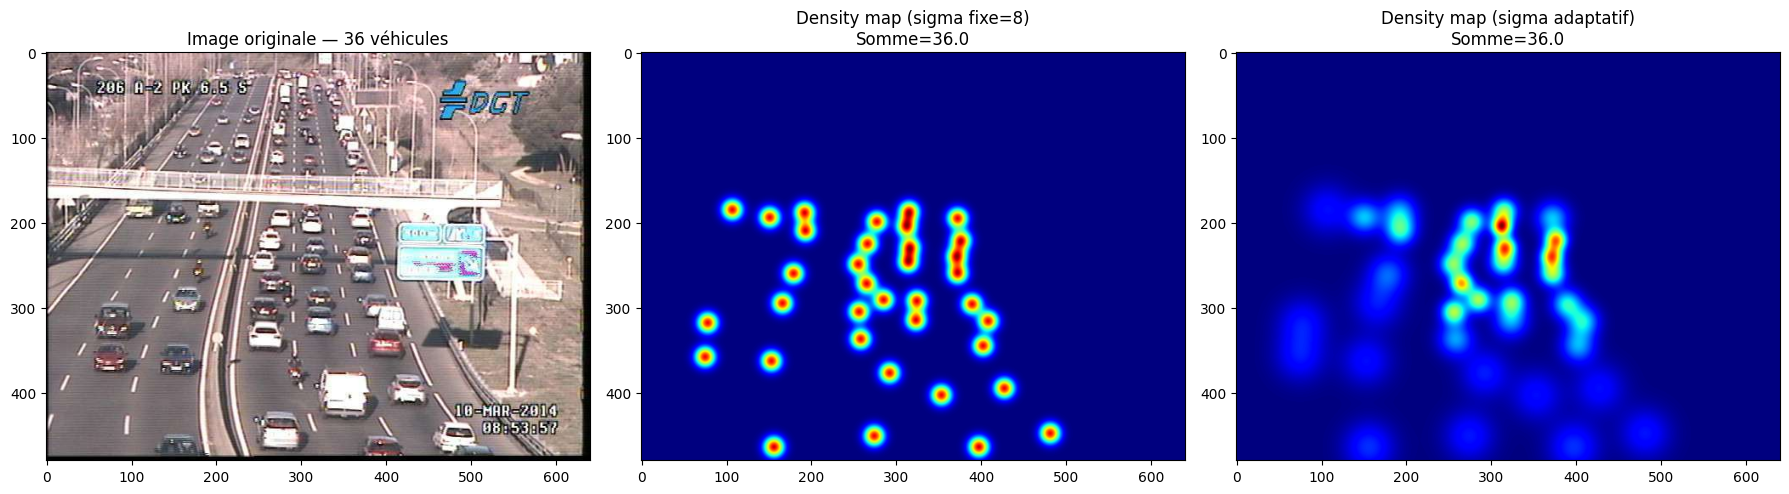

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img)
axes[0].set_title(f"Image originale — {len(points)} véhicules")

axes[1].imshow(dm_fixed, cmap='jet')
axes[1].set_title(f"Density map (sigma fixe=8)\nSomme={dm_fixed.sum():.1f}")

axes[2].imshow(dm_adaptive, cmap='jet')
axes[2].set_title(f"Density map (sigma adaptatif)\nSomme={dm_adaptive.sum():.1f}")

plt.tight_layout()
plt.show()

### Génération en masse et mise en cache

Les cartes de densité sont générées pour l'ensemble des échantillons de
`train_data` et `test_data`, avec les mêmes paramètres (méthode adaptative,
k=3, beta=0.3) pour garantir la cohérence entre les deux splits, puis
sauvegardées au format `.npy` pour éviter de les recalculer à chaque epoch.

In [16]:
import os

def generate_and_cache_density_maps(split_dir, common_ids, method="fixed", sigma=8,
                                      k=3, beta=0.3, output_subdir="density_maps"):
    """
    Génère et sauvegarde les density maps pour tous les échantillons d'un split.
    method: "fixed" ou "adaptive"
    """
    images_dir = split_dir / "images"
    txt_dir = split_dir / "txt"
    gt_dir = split_dir / "ground-truth"

    output_dir = split_dir / output_subdir
    output_dir.mkdir(exist_ok=True)

    failed = []
    sanity_failures = []

    for i, sample_id in enumerate(common_ids):
        try:
            img = Image.open(images_dir / f"{sample_id}.jpg")
            w, h = img.size

            points = load_points(txt_dir / f"{sample_id}.txt")
            roi = loadmat(str(gt_dir / f"{sample_id}mask.mat"))["BW"]

            binary_map = points_to_binary_map(points, shape=(h, w))

            if method == "fixed":
                dm = density_map_fixed_sigma(binary_map, sigma=sigma)
            else:
                dm = density_map_adaptive_sigma(binary_map, points, k=k, beta=beta)

            dm = apply_roi(dm, roi)

            # Test de sanité silencieux (on log seulement les échecs)
            total = dm.sum()
            diff = abs(total - len(points))
            if len(points) > 0 and diff > 0.05 * len(points):
                sanity_failures.append((sample_id, total, len(points)))

            np.save(output_dir / f"{sample_id}.npy", dm.astype(np.float32))

        except Exception as e:
            failed.append((sample_id, str(e)))

        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(common_ids)} traités...")

    print(f"\nTerminé : {len(common_ids) - len(failed)} / {len(common_ids)} density maps générées.")
    if failed:
        print(f"Echecs : {len(failed)} -> {failed[:5]}")
    if sanity_failures:
        print(f"\nAlertes sanity check (diff > 5%) : {len(sanity_failures)}")
        for sid, total, expected in sanity_failures[:5]:
            print(f"  {sid}: somme={total:.2f}, attendu={expected}")

    return failed, sanity_failures

In [17]:
# Adaptez split_dir selon TRAIN_DIR ou TEST_DIR, et common_ids correspondant
failed, sanity_failures = generate_and_cache_density_maps(
    split_dir=TRAIN_DIR,
    common_ids=common_ids,   # liste obtenue à l'étape 0
    method="adaptive",        # ou "fixed"
    sigma=8,
    k=3,
    beta=0.3,
)

  100/1031 traités...
  200/1031 traités...
  300/1031 traités...
  400/1031 traités...
  500/1031 traités...
  600/1031 traités...
  700/1031 traités...
  800/1031 traités...
  900/1031 traités...
  1000/1031 traités...

Terminé : 0 / 1031 density maps générées.
Echecs : 1031 -> [('image-1-000001', "name 'density_map_adaptive_sigma' is not defined"), ('image-1-000002', "name 'density_map_adaptive_sigma' is not defined"), ('image-1-000003', "name 'density_map_adaptive_sigma' is not defined"), ('image-1-000004', "name 'density_map_adaptive_sigma' is not defined"), ('image-1-000005', "name 'density_map_adaptive_sigma' is not defined")]


In [18]:
# Construire les IDs communs pour test_data (même logique que pour train à l'étape 0)
test_common_ids = sorted(
    get_ids(TEST_DIR / "images", ".jpg") &
    get_ids(TEST_DIR / "txt", ".txt") &
    get_ids(TEST_DIR / "ground-truth", "mask.mat") &
    get_ids(TEST_DIR / "dots", "dots.png")
)

print(f"Nombre d'échantillons test : {len(test_common_ids)}")  # devrait afficher 213

failed_test, sanity_failures_test = generate_and_cache_density_maps(
    split_dir=TEST_DIR,
    common_ids=test_common_ids,
    method="adaptive",   # même méthode que pour train, important pour la cohérence
    sigma=8,
    k=3,
    beta=0.3,
)

Nombre d'échantillons test : 213
  100/213 traités...
  200/213 traités...

Terminé : 0 / 213 density maps générées.
Echecs : 213 -> [('image-1-000333', "name 'density_map_adaptive_sigma' is not defined"), ('image-1-000334', "name 'density_map_adaptive_sigma' is not defined"), ('image-1-000335', "name 'density_map_adaptive_sigma' is not defined"), ('image-1-000336', "name 'density_map_adaptive_sigma' is not defined"), ('image-1-000337', "name 'density_map_adaptive_sigma' is not defined")]


## Étape 2 : Prétraitement et augmentation

Cette étape prépare les images et leurs cartes de densité associées pour
l'entraînement : normalisation, redimensionnement cohérent, et augmentation
de données légère.

In [21]:
# Construire les IDs communs pour train_data 
train_common_ids = sorted(
    get_ids(TRAIN_DIR / "images", ".jpg") &
    get_ids(TRAIN_DIR / "txt", ".txt") &
    get_ids(TRAIN_DIR / "ground-truth", "mask.mat") &
    get_ids(TRAIN_DIR / "dots", "dots.png")
)

###  Separation des donnees de Train en train et validation

In [22]:
import random
random.seed(42)  # reproductibilité

ids_shuffled = train_common_ids.copy()
random.shuffle(ids_shuffled)

n_val = int(0.2 * len(ids_shuffled))
val_ids = sorted(ids_shuffled[:n_val])
train_ids_final = sorted(ids_shuffled[n_val:])

print(f"Train final : {len(train_ids_final)} | Val : {len(val_ids)}")

Train final : 825 | Val : 206


### Normalisation des images (statistiques ImageNet)

Les images sont normalisées avec les moyennes et écarts-types standards
d'ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), pour
rester cohérent avec le backbone VGG-16 pré-entraîné utilisé dans CSRNet.

In [23]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def normalize_image(img_array):
    """img_array : float32, valeurs dans [0,1], shape (H, W, 3)"""
    return (img_array - IMAGENET_MEAN) / IMAGENET_STD

###  Redimensionnement cohérent image + density map
Deux contraintes à respecter simultanément :

. CSRNet réduit la résolution par 8 → la hauteur et la largeur doivent être divisibles par 8, sinon des erreurs de shape apparaîtront au moment de comparer prédiction et cible.

. Si on redimensionne l'image, il faut recalculer la density map par interpolation puis renormaliser pour préserver le comptage total (sinon le redimensionnement fausse la somme = le nombre de véhicules)

In [24]:
import cv2

def resize_to_multiple_of_8(img_array, density_map):
    """Redimensionne image et density map à la dimension multiple de 8 la plus proche,
    en préservant le comptage total de la density map."""
    h, w = img_array.shape[:2]
    new_h = (h // 8) * 8
    new_w = (w // 8) * 8

    if (new_h, new_w) == (h, w):
        return img_array, density_map  # déjà multiple de 8

    img_resized = cv2.resize(img_array, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    original_sum = density_map.sum()
    dm_resized = cv2.resize(density_map, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    new_sum = dm_resized.sum()
    if new_sum > 0:
        dm_resized *= (original_sum / new_sum)  # renormalisation : préserve le comptage

    return img_resized, dm_resized

#### Test de sanité obligatoire après resize :

In [25]:
img_arr = np.array(img, dtype=np.float32) / 255.0
img_r, dm_r = resize_to_multiple_of_8(img_arr, dm_adaptive_roi)
print(f"Avant resize: {dm_adaptive_roi.sum():.4f} | Après resize: {dm_r.sum():.4f}")

Avant resize: 34.7107 | Après resize: 34.7107


### Augmentation de données : crop aléatoire, luminosité, bruit

Un crop aléatoire est appliqué de façon identique sur l'image et sa carte de
densité (pour préserver l'alignement spatial), suivi d'une variation de
luminosité et d'un bruit gaussien léger appliqués uniquement à l'image.

**Choix méthodologique : pas de flip horizontal/vertical.** Les caméras TRANCOS
sont fixes, avec une perspective routière cohérente (sens de circulation,
disposition des voies). Un flip inverserait artificiellement la géométrie de
la scène, ce qui n'a pas de sens physique pour ce type de données — contrairement
à une tâche de classification d'objets génériques où cette augmentation est
neutre.

In [26]:
def random_crop(img, density_map, crop_size=(384, 384)):
    """Crop aléatoire identique sur l'image et la density map (alignement spatial)."""
    h, w = img.shape[:2]
    ch, cw = crop_size
    ch, cw = min(ch, h), min(cw, w)

    top = np.random.randint(0, h - ch + 1)
    left = np.random.randint(0, w - cw + 1)

    img_cropped = img[top:top+ch, left:left+cw]
    dm_cropped = density_map[top:top+ch, left:left+cw]
    return img_cropped, dm_cropped


def random_brightness(img, factor_range=(0.8, 1.2)):
    """Variation de luminosité. Ne touche QUE l'image, pas la density map."""
    factor = np.random.uniform(*factor_range)
    return np.clip(img * factor, 0, 1)


def add_gaussian_noise(img, std=0.02):
    """Bruit gaussien léger sur l'image uniquement."""
    noise = np.random.normal(0, std, img.shape).astype(np.float32)
    return np.clip(img + noise, 0, 1)

#### Assembler en pipeline complet (fonction à appeler par image)

In [27]:
def preprocess_sample(img_array, density_map, training=True, crop_size=(384, 384)):
    """img_array : float32 [0,1], shape (H,W,3) ; density_map : float32, shape (H,W)"""

    img, dm = resize_to_multiple_of_8(img_array, density_map)

    if training:
        img, dm = random_crop(img, dm, crop_size=crop_size)
        img = random_brightness(img)
        img = add_gaussian_noise(img)
    # Pas de crop aléatoire ni d'augmentation en validation/test -> évaluation déterministe

    img = normalize_image(img)
    return img, dm

### Validation visuelle du pipeline de prétraitement

Vérification qualitative : l'image augmentée et sa carte de densité croppée
restent cohérentes (les pics de densité correspondent visuellement aux
positions des véhicules visibles après crop).

Avant: image (480, 640, 3), density map somme=34.18
Après: image (384, 384, 3), density map somme=28.00


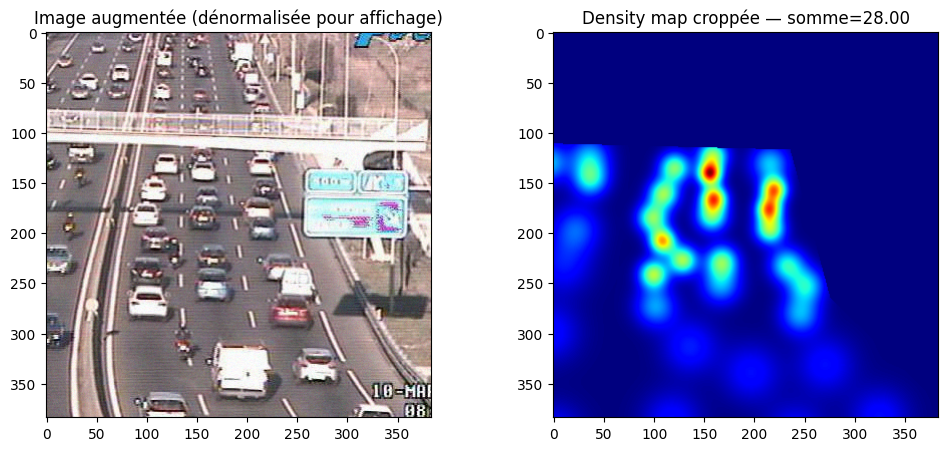

In [28]:
sample_id = train_ids_final[0]
img_arr = np.array(Image.open(images_dir / f"{sample_id}.jpg"), dtype=np.float32) / 255.0
dm = np.load(TRAIN_DIR / "density_maps" / f"{sample_id}.npy")

print(f"Avant: image {img_arr.shape}, density map somme={dm.sum():.2f}")

img_p, dm_p = preprocess_sample(img_arr, dm, training=True)
print(f"Après: image {img_p.shape}, density map somme={dm_p.sum():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow((img_p * IMAGENET_STD + IMAGENET_MEAN).clip(0,1))
axes[0].set_title("Image augmentée (dénormalisée pour affichage)")
axes[1].imshow(dm_p, cmap='jet')
axes[1].set_title(f"Density map croppée — somme={dm_p.sum():.2f}")
plt.show()

## Étape 3 : Implémentation de l'architecture CSRNet

CSRNet combine un front-end convolutif (VGG-16 tronqué, pré-entraîné sur
ImageNet) et un back-end de convolutions dilatées, permettant d'élargir le
champ réceptif sans réduire davantage la résolution spatiale — une propriété
essentielle pour la régression dense de carte de densité.

In [29]:
import torch
import torch.nn as nn
import torchvision.models as models

### Front-end : VGG-16 tronqué (jusqu'à conv4_3)

Seules les couches convolutives de VGG-16 jusqu'à `conv4_3` sont conservées
(13 couches, 3 max-poolings au lieu de 5), supprimant le 4e et 5e bloc de
pooling/convolution ainsi que toutes les couches fully-connected. Les poids
pré-entraînés sur ImageNet sont conservés pour ce front-end.

In [30]:
def make_vgg_frontend(pretrained=True):
    """
    Retourne les couches conv de VGG-16 jusqu'à conv4_3 (incluse),
    SANS le 4e maxpool (pour préserver davantage de résolution spatiale,
    compensé ensuite par les convolutions dilatées du back-end).
    """
    vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None)

    # vgg.features contient les blocs : conv1_1...conv1_2, pool1, conv2_1...conv2_2, pool2,
    # conv3_1...conv3_3, pool3, conv4_1...conv4_3, pool4, conv5_1...conv5_3, pool5
    # On garde tout jusqu'à conv4_3 (index 22 inclus dans vgg16.features), on retire pool4 et après.
    layers = list(vgg.features.children())[:23]  # jusqu'à conv4_3 + ReLU, AVANT pool4
    frontend = nn.Sequential(*layers)
    return frontend

#### Vérification de la troncature :

In [31]:
vgg_test = models.vgg16(weights=None)
for i, layer in enumerate(vgg_test.features):
    print(i, layer)

0 Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
1 ReLU(inplace=True)
2 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
3 ReLU(inplace=True)
4 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
5 Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
6 ReLU(inplace=True)
7 Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
8 ReLU(inplace=True)
9 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
10 Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
11 ReLU(inplace=True)
12 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
13 ReLU(inplace=True)
14 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
15 ReLU(inplace=True)
16 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
17 Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
18 ReLU(inplace=True)
19 Conv2d(512, 512, kernel_size=(3, 3)

### Back-end : convolutions dilatées (taux=2)

6 couches convolutives avec un taux de dilatation de 2 (conformément à
l'énoncé [2,2,2,2,2]), réduisant progressivement le nombre de canaux
(512 → 512 → 512 → 256 → 128 → 64). Le padding est ajusté pour égaler la
dilation, ce qui préserve la résolution spatiale à chaque couche.

In [32]:
def make_dilated_backend():
    """
    6 couches convolutives dilatées (taux=2), comme spécifié dans l'énoncé [2,2,2,2,2],
    réduisant progressivement les canaux 512 -> 256 -> 128 -> 64.
    """
    layers = [
        nn.Conv2d(512, 512, kernel_size=3, dilation=2, padding=2), nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, dilation=2, padding=2), nn.ReLU(inplace=True),
        nn.Conv2d(512, 512, kernel_size=3, dilation=2, padding=2), nn.ReLU(inplace=True),
        nn.Conv2d(512, 256, kernel_size=3, dilation=2, padding=2), nn.ReLU(inplace=True),
        nn.Conv2d(256, 128, kernel_size=3, dilation=2, padding=2), nn.ReLU(inplace=True),
        nn.Conv2d(128, 64,  kernel_size=3, dilation=2, padding=2), nn.ReLU(inplace=True),
    ]
    return nn.Sequential(*layers)

### Couche de sortie et assemblage du modèle complet

Une convolution finale 1×1 produit la carte de densité estimée (1 canal).
Le back-end et la couche de sortie sont initialisés selon une loi normale
(std=0.01), suivant les recommandations du papier CSRNet original, tandis que
le front-end VGG conserve ses poids ImageNet.

In [33]:
def make_output_layer():
    return nn.Conv2d(64, 1, kernel_size=1)

In [34]:
class CSRNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.frontend = make_vgg_frontend(pretrained=pretrained)
        self.backend = make_dilated_backend()
        self.output_layer = make_output_layer()

        if pretrained:
            self._init_backend_weights()

    def _init_backend_weights(self):
        """Initialisation normale (std=0.01) pour le back-end et la sortie,
        comme recommandé dans le papier CSRNet original — le front-end VGG
        garde ses poids ImageNet pré-entraînés."""
        for layer in [self.backend, self.output_layer]:
            for m in layer.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.normal_(m.weight, std=0.01)
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.output_layer(x)
        return x

### Vérification du ratio de résolution 1/8

Test sur une entrée factice (384×384) : la sortie obtenue est bien de 48×48,
confirmant un ratio de réduction exact de 8, conforme à la spécification de
l'architecture.

In [35]:
model = CSRNet(pretrained=True)
model.eval()

dummy_input = torch.randn(1, 3, 384, 384)  # cohérent avec votre crop_size
with torch.no_grad():
    output = model(dummy_input)

print(f"Input shape  : {dummy_input.shape}")
print(f"Output shape : {output.shape}")
print(f"Ratio H : {dummy_input.shape[2] / output.shape[2]}")
print(f"Ratio W : {dummy_input.shape[3] / output.shape[3]}")

Input shape  : torch.Size([1, 3, 384, 384])
Output shape : torch.Size([1, 1, 48, 48])
Ratio H : 8.0
Ratio W : 8.0




### Stratégie de gel/dégel du front-end

Avec un dataset d'entraînement de taille modeste (~1000 images), le front-end
VGG est gelé en début d'entraînement pour limiter le risque de surapprentissage,
puis dégelé progressivement après un nombre d'epochs déterminé, avec un
learning rate réduit, pour un fine-tuning plus fin.

In [36]:
def freeze_frontend(model, freeze=True):
    """Gèle (ou dégèle) les poids du front-end VGG pré-entraîné."""
    for param in model.frontend.parameters():
        param.requires_grad = not freeze

# Stratégie recommandée pour un dataset de taille modeste comme TRANCOS (1031 images train) :
# geler le frontend dans les premières epochs, puis le dégeler pour fine-tuning progressif.
freeze_frontend(model, freeze=True)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Paramètres entraînables : {n_trainable:,} / {n_total:,} ({n_trainable/n_total:.1%})")

Paramètres entraînables : 8,628,225 / 16,263,489 (53.1%)


## Étape 4 : Entraînement

Mise en place du pipeline complet d'entraînement : chargement des données,
loss pondérée spatialement, optimisation, et suivi des métriques sur
validation.

### Dataset et DataLoader PyTorch

La classe `TrancosDataset` charge l'image et sa carte de densité associée,
applique le pipeline de prétraitement/augmentation (étape 2), puis réduit la
carte de densité cible à la résolution de sortie du modèle (1/8), avec
renormalisation pour préserver le comptage total. Le batch size est fixé à 1
en raison des dimensions d'image variables après redimensionnement.

In [37]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
from pathlib import Path


class TrancosDataset(Dataset):
    def __init__(self, split_dir, ids_list, training=True, crop_size=(384, 384)):
        self.split_dir = Path(split_dir)
        self.images_dir = self.split_dir / "images"
        self.dm_dir = self.split_dir / "density_maps"
        self.ids_list = ids_list
        self.training = training
        self.crop_size = crop_size

    def __len__(self):
        return len(self.ids_list)

    def __getitem__(self, idx):
        sample_id = self.ids_list[idx]

        img = Image.open(self.images_dir / f"{sample_id}.jpg").convert("RGB")
        img_arr = np.array(img, dtype=np.float32) / 255.0

        dm = np.load(self.dm_dir / f"{sample_id}.npy")

        img_p, dm_p = preprocess_sample(img_arr, dm, training=self.training, crop_size=self.crop_size)
        dm_p = downsample_density_map(dm_p, factor=8)
        # (H, W, 3) -> (3, H, W) pour PyTorch
        img_tensor = torch.from_numpy(img_p.transpose(2, 0, 1)).float()
        # Density map réduite à 1/8 (résolution de sortie du modèle)
        dm_tensor = torch.from_numpy(dm_p).float().unsqueeze(0)  # (1, H, W)

        return img_tensor, dm_tensor, sample_id

**Point important :** la density map cible doit être à 1/8, pas à la taille de l'image
Le modèle sort du 48×48 pour une entrée 384×384. Or dm_p après preprocessing est à 384×384. Il faut donc soit redimensionner la cible à 1/8 dans le Dataset, soit upsampler la sortie du modèle. La convention CSRNet standard est de downsampler la density map cible, en renormalisant pour préserver le comptage (même logique qu'à l'étape 2) :

In [38]:
import cv2

def downsample_density_map(dm, factor=8):
    h, w = dm.shape
    new_h, new_w = h // factor, w // factor
    original_sum = dm.sum()
    dm_small = cv2.resize(dm, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    new_sum = dm_small.sum()
    if new_sum > 0:
        dm_small *= (original_sum / new_sum)
    return dm_small

 #### Instancier les datasets et dataloaders
 
 batch_size=1 car les images ne sont pas toutes de même taille après resize (multiple de 8), donc on ne peut pas les empiler en batch sans padding. C'est cohérent avec ce qui est noté dans le plan (batch size souvent =1 pour ce type de réseau densité).

In [39]:
train_dataset = TrancosDataset(TRAIN_DIR, train_ids_final, training=True, crop_size=(384, 384))
val_dataset = TrancosDataset(TRAIN_DIR, val_ids, training=False, crop_size=(384, 384))
test_dataset = TrancosDataset(TEST_DIR, test_common_ids, training=False, crop_size=(384, 384))

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

#### Test rapide du DataLoader

In [40]:
img_batch, dm_batch, ids_batch = next(iter(train_loader))
print(f"Image batch shape : {img_batch.shape}")
print(f"Density map batch shape : {dm_batch.shape}")
print(f"Somme density map (cible réduite) : {dm_batch.sum().item():.2f}")

Image batch shape : torch.Size([1, 3, 384, 384])
Density map batch shape : torch.Size([1, 1, 48, 48])
Somme density map (cible réduite) : 35.32


### Loss avec pondération spatiale

Une MSE pondérée est utilisée : les pixels de forte densité (au-delà d'un
seuil) reçoivent un poids plus élevé dans le calcul de la loss, afin
d'éviter que le modèle ne sous-estime systématiquement les zones de forte
congestion — un biais classique documenté pour ce type de tâche.

In [41]:
class WeightedMSELoss(torch.nn.Module):
    def __init__(self, weight_factor=2.0, density_threshold=0.5):
        """
        weight_factor : multiplicateur de poids appliqué aux pixels de forte densité.
        density_threshold : seuil au-delà duquel un pixel est considéré 'haute densité'.
        """
        super().__init__()
        self.weight_factor = weight_factor
        self.density_threshold = density_threshold

    def forward(self, pred, target):
        weights = torch.ones_like(target)
        weights[target > self.density_threshold] = self.weight_factor

        loss = weights * (pred - target) ** 2
        return loss.mean()

### Modèle, optimiseur, scheduler


In [42]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

model = CSRNet(pretrained=True).to(device)
freeze_frontend(model, freeze=True)  # gel initial du frontend

criterion = WeightedMSELoss(weight_factor=2.0, density_threshold=0.5)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

Device utilisé : cpu


In [43]:
def compute_mae(pred, target):
    """MAE sur le comptage total (somme de la density map), pas pixel-wise."""
    return abs(pred.sum().item() - target.sum().item())


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for img, dm, _ in loader:
        img, dm = img.to(device), dm.to(device)
        optimizer.zero_grad()
        pred = model(img)
        loss = criterion(pred, dm)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_mae = 0.0
    with torch.no_grad():
        for img, dm, _ in loader:
            img, dm = img.to(device), dm.to(device)
            pred = model(img)
            loss = criterion(pred, dm)
            total_loss += loss.item()
            total_mae += compute_mae(pred, dm)
    return total_loss / len(loader), total_mae / len(loader)

### Boucle d'entraînement avec validation

À chaque epoch : passage d'entraînement sur le train set, évaluation sur le
validation set (loss + MAE sur le comptage), et sauvegarde du meilleur modèle
selon le MAE de validation.

In [ ]:
import os
import torch
import torch.optim as optim

N_EPOCHS = 30
UNFREEZE_EPOCH = 10

# 1. Initialisation par défaut
start_epoch = 0
best_val_mae = float("inf")
history = {"train_loss": [], "val_loss": [], "val_mae": []}

# Définir l'optimiseur par défaut (frontend bloqué au départ)
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Ajustez votre LR de départ si nécessaire

# Chemins sur votre Google Drive
chemin_meilleur_modele = "best_csrnet.pth"
chemin_checkpoint = "csrnet_checkpoint.pth"

# 2. VÉRIFICATION ET REPRISE AUTOMATIQUE SI LE KERNEL A RESTART
if os.path.exists(chemin_checkpoint):
    print(">>> Un checkpoint a été trouvé! Chargement de l'état précédent... <<<")
    checkpoint = torch.load(chemin_checkpoint)
    
    # Restauration des variables de contrôle
    start_epoch = checkpoint['epoch'] + 1
    best_val_mae = checkpoint['best_val_mae']
    history = checkpoint['history']
    
    # Restauration des poids du modèle
    model.load_state_dict(checkpoint['state_dict'])
    
    # Recréation de l'optimiseur selon l'époque atteinte
    if start_epoch >= UNFREEZE_EPOCH:
        print(">>> Reprise après l'époque de dégel. Configuration de l'optimiseur fine-tuning <<<")
        freeze_frontend(model, freeze=False)
        optimizer = optim.Adam(model.parameters(), lr=1e-5)
    
    # Restauration de l'état de l'optimiseur
    optimizer.load_state_dict(checkpoint['optimizer'])
    print(f">>> Reprise réussie ! Reprise à partir de l'époque {start_epoch + 1} <<<")

# 3. La boucle d'entraînement (démarre à start_epoch au lieu de 0)
for epoch in range(start_epoch, N_EPOCHS):
    if epoch == UNFREEZE_EPOCH:
        print(">>> Dégel du frontend VGG pour fine-tuning <<<")
        freeze_frontend(model, freeze=False)
        optimizer = optim.Adam(model.parameters(), lr=1e-5)

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_mae = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)

    print(f"Epoch {epoch+1}/{N_EPOCHS} | Train loss: {train_loss:.4f} | "
          f"Val loss: {val_loss:.4f} | Val MAE: {val_mae:.2f}")

    # Sauvegarde du MEILLEUR modèle (votre code existant)
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), chemin_meilleur_modele)
        print(f"  -> Nouveau meilleur modèle sauvegardé sur votre Google Drive (Val MAE: {val_mae:.2f})")

    # SAUVEGARDE DU CHECKPOINT DE SÉCURITÉ (À chaque époque)
    # On enregistre tout pour pouvoir reprendre en cas de crash du kernel
    checkpoint_state = {
        'epoch': epoch,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'best_val_mae': best_val_mae,
        'history': history
    }
    torch.save(checkpoint_state, chemin_checkpoint)
    print("  -> Checkpoint de sécurité mis à jour.")

>>> Un checkpoint a été trouvé! Chargement de l'état précédent... <<<
>>> Reprise réussie ! Reprise à partir de l'époque 9 <<<
Epoch 9/30 | Train loss: 0.0005 | Val loss: 0.0006 | Val MAE: 5.13
  -> Checkpoint de sécurité mis à jour.
Epoch 10/30 | Train loss: 0.0004 | Val loss: 0.0007 | Val MAE: 4.91
  -> Checkpoint de sécurité mis à jour.
>>> Dégel du frontend VGG pour fine-tuning <<<
Epoch 11/30 | Train loss: 0.0004 | Val loss: 0.0006 | Val MAE: 4.37
  -> Nouveau meilleur modèle sauvegardé sur votre Google Drive (Val MAE: 4.37)
  -> Checkpoint de sécurité mis à jour.
Epoch 12/30 | Train loss: 0.0003 | Val loss: 0.0006 | Val MAE: 4.71
  -> Checkpoint de sécurité mis à jour.
Epoch 13/30 | Train loss: 0.0003 | Val loss: 0.0006 | Val MAE: 5.27
  -> Checkpoint de sécurité mis à jour.
Epoch 14/30 | Train loss: 0.0003 | Val loss: 0.0006 | Val MAE: 4.17
  -> Nouveau meilleur modèle sauvegardé sur votre Google Drive (Val MAE: 4.17)
  -> Checkpoint de sécurité mis à jour.
Epoch 15/30 | Train l

### Courbes d'apprentissage

Visualisation de l'évolution de la train loss, de la val loss et du val MAE
au fil des epochs, avec repère visuel du moment de dégel du front-end.

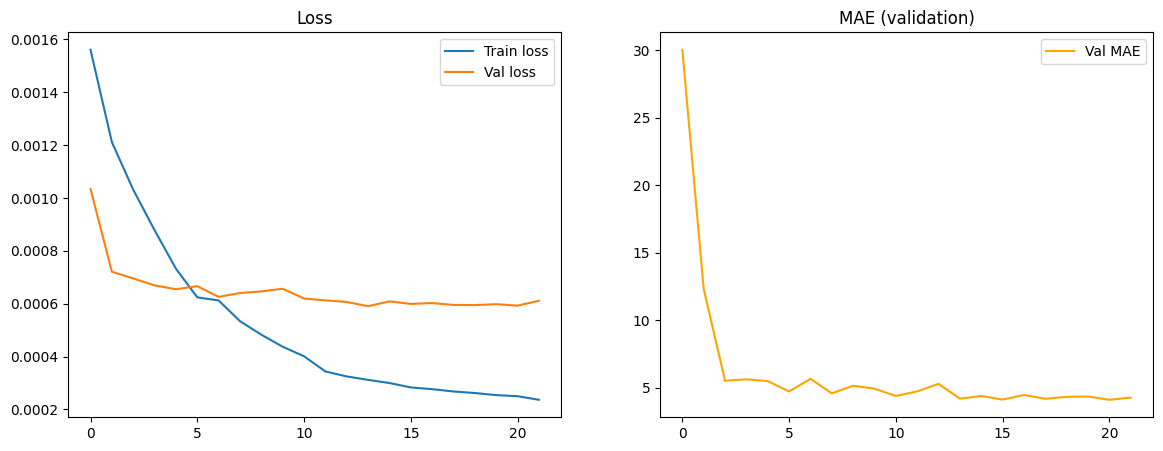

In [48]:
import os
import torch
import matplotlib.pyplot as plt

# 1. SÉCURITÉ : Si le kernel a restart et que 'history' n'est pas en mémoire,
# on va le charger directement depuis le checkpoint du Drive
if 'history' not in locals() or not history["train_loss"]:
    chemin_checkpoint = "csrnet_checkpoint.pth"
    
    if os.path.exists(chemin_checkpoint):
        print(">>> Récupération de l'historique depuis le checkpoint du Drive... <<<")
        checkpoint = torch.load(chemin_checkpoint)
        history = checkpoint['history']
        # On récupère aussi l'UNFREEZE_EPOCH si elle n'est pas définie
        if 'UNFREEZE_EPOCH' not in locals():
            UNFREEZE_EPOCH = 10 
    else:
        print("❌ Aucun historique en mémoire et aucun checkpoint trouvé sur le Drive.")
        # Initialisation vide pour éviter que le code de traçage ne plante
        history = {"train_loss": [], "val_loss": [], "val_mae": []}

# 2. TRACÉ DES GRAPHIQUES (Ton code d'origine, s'exécute sans problème maintenant)
if history["train_loss"]: # On ne trace que s'il y a des données
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_loss"], label="Train loss")
    axes[0].plot(history["val_loss"], label="Val loss")
    #axes[0].axvline(UNFREEZE_EPOCH, color='red', linestyle='--', label="Dégel frontend")
    axes[0].legend()
    axes[0].set_title("Loss")

    axes[1].plot(history["val_mae"], label="Val MAE", color='orange')
    #axes[1].axvline(UNFREEZE_EPOCH, color='red', linestyle='--')
    axes[1].legend()
    axes[1].set_title("MAE (validation)")
    plt.show()
else:
    print("Pas de données à afficher pour le moment (l'entraînement n'a pas encore commencé).")

## Étape 5 : Évaluation rigoureuse

Le modèle final est évalué sur le test set de TRANCOS à l'aide de métriques
standards pour les tâches de comptage par densité (et non des métriques de
classification telles que accuracy/F1, qui ne s'appliquent pas à ce problème).

In [49]:
model = CSRNet(pretrained=True).to(device)
model.load_state_dict(torch.load("best_csrnet.pth", map_location=device))
model.eval()
print("Modèle chargé.")

Modèle chargé.




### MAE et MSE sur le comptage total

Pour chaque image de test, l'écart entre le comptage prédit (somme de la carte
de densité estimée) et le comptage réel (somme de la carte de densité cible)
est calculé, puis moyenné sur l'ensemble du test set.

In [50]:
import numpy as np

def evaluate_counting_metrics(model, loader, device):
    model.eval()
    abs_errors = []
    sq_errors = []
    results = []

    with torch.no_grad():
        for img, dm, sample_id in loader:
            img, dm = img.to(device), dm.to(device)
            pred = model(img)

            pred_count = pred.sum().item()
            true_count = dm.sum().item()

            err = pred_count - true_count
            abs_errors.append(abs(err))
            sq_errors.append(err ** 2)

            results.append((sample_id[0], pred_count, true_count, err))

    mae = np.mean(abs_errors)
    mse = np.mean(sq_errors)
    rmse = np.sqrt(mse)

    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")

    return mae, mse, rmse, results

mae, mse, rmse, test_results = evaluate_counting_metrics(model, test_loader, device)

MAE  : 5.533
MSE  : 57.242
RMSE : 7.566




### Métrique GAME (Grid Average Mean absolute Error)

Métrique spécifique à TRANCOS : l'image est subdivisée en grilles de plus en
plus fines (niveaux L=0 à 3), et le MAE est calculé sur chaque sous-région
avant moyennage. GAME(L=0) est équivalent au MAE global ; les niveaux
supérieurs pénalisent davantage les erreurs de localisation spatiale, même
lorsque le comptage global est correct.

Note : GAME(L=0) est mathématiquement identique au MAE global calculé en cellule 2 (pas de subdivision). Plus L augmente, plus la métrique pénalise les erreurs de localisation spatiale, même si le comptage total est correct.

In [51]:
def game_metric(pred_map, true_map, L):
    """
    pred_map, true_map : tensors (1, 1, H, W) ou arrays numpy (H, W)
    L : niveau de subdivision (0 = pas de découpage, 1 = 2x2, 2 = 4x4, 3 = 8x8)
    """
    if isinstance(pred_map, torch.Tensor):
        pred_map = pred_map.squeeze().cpu().numpy()
    if isinstance(true_map, torch.Tensor):
        true_map = true_map.squeeze().cpu().numpy()

    h, w = true_map.shape
    n_splits = 2 ** L

    h_step = h // n_splits
    w_step = w // n_splits

    total_error = 0.0
    for i in range(n_splits):
        for j in range(n_splits):
            h_start, h_end = i * h_step, (i + 1) * h_step if i < n_splits - 1 else h
            w_start, w_end = j * w_step, (j + 1) * w_step if j < n_splits - 1 else w

            pred_region_sum = pred_map[h_start:h_end, w_start:w_end].sum()
            true_region_sum = true_map[h_start:h_end, w_start:w_end].sum()

            total_error += abs(pred_region_sum - true_region_sum)

    return total_error


def evaluate_game(model, loader, device, levels=(0, 1, 2, 3)):
    model.eval()
    game_scores = {L: [] for L in levels}

    with torch.no_grad():
        for img, dm, sample_id in loader:
            img, dm = img.to(device), dm.to(device)
            pred = model(img)

            for L in levels:
                score = game_metric(pred, dm, L)
                game_scores[L].append(score)

    results = {}
    for L in levels:
        mean_game = np.mean(game_scores[L])
        results[L] = mean_game
        print(f"GAME(L={L}) : {mean_game:.3f}")

    return results

game_results = evaluate_game(model, test_loader, device, levels=(0, 1, 2, 3))

GAME(L=0) : 5.533
GAME(L=1) : 7.438
GAME(L=2) : 8.906
GAME(L=3) : 10.817


#### Diagnostic des pires/meilleures prédictions

In [52]:
results_sorted = sorted(test_results, key=lambda x: -abs(x[3]))  # tri par erreur absolue décroissante

print("Top 5 PIRES prédictions :")
for sid, pred_c, true_c, err in results_sorted[:5]:
    print(f"  {sid}: prédit={pred_c:.1f}, vrai={true_c:.1f}, erreur={err:+.1f}")

print("\nTop 5 MEILLEURES prédictions :")
for sid, pred_c, true_c, err in results_sorted[-5:]:
    print(f"  {sid}: prédit={pred_c:.1f}, vrai={true_c:.1f}, erreur={err:+.1f}")

Top 5 PIRES prédictions :
  image-3-000413: prédit=43.6, vrai=73.9, erreur=-30.3
  image-3-000408: prédit=34.3, vrai=59.7, erreur=-25.4
  image-3-000410: prédit=42.2, vrai=65.8, erreur=-23.6
  image-3-000356: prédit=26.1, vrai=48.1, erreur=-22.0
  image-3-000411: prédit=43.7, vrai=63.9, erreur=-20.2

Top 5 MEILLEURES prédictions :
  image-1-000342: prédit=16.7, vrai=16.5, erreur=+0.2
  image-3-000390: prédit=26.5, vrai=26.4, erreur=+0.2
  image-3-000383: prédit=13.1, vrai=13.0, erreur=+0.1
  image-3-000358: prédit=40.1, vrai=40.2, erreur=-0.0
  image-3-000389: prédit=25.7, vrai=25.7, erreur=-0.0


### Visualisation qualitative : prédiction vs vérité terrain

Comparaison visuelle, sur un échantillon donné, entre l'image originale, la
carte de densité de référence et la carte de densité prédite par le modèle.



******************VISUALISATION DE LA MEILLEURE PREDICTION******************************


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


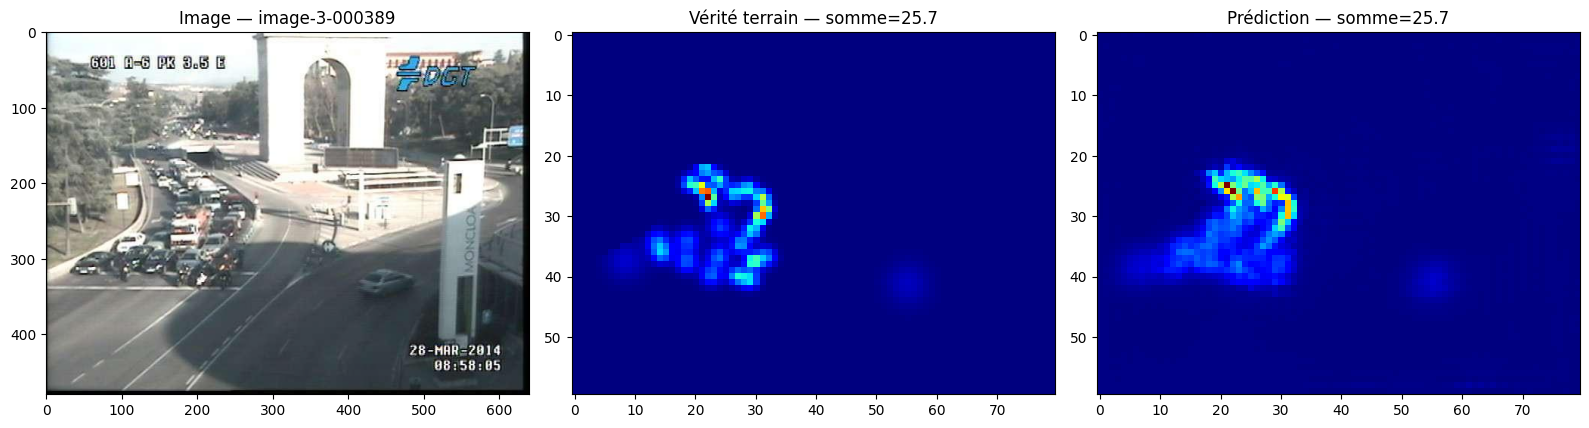




***********************VISUALISATION DE LA PIRE PREDICTION****************************




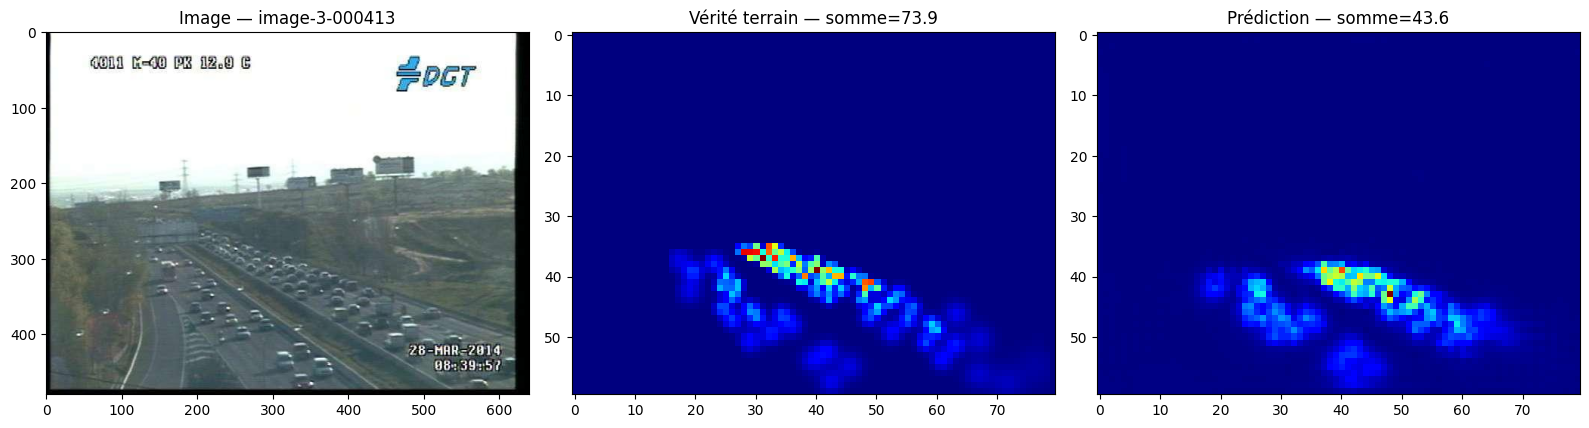

In [59]:
import matplotlib.pyplot as plt

def visualize_prediction(model, dataset, sample_idx, device):
    img, dm, sample_id = dataset[sample_idx]
    img_batch = img.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(img_batch).squeeze().cpu().numpy()

    true_dm = dm.squeeze().numpy()
    img_display = (img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(img_display)
    axes[0].set_title(f"Image — {sample_id}")

    axes[1].imshow(true_dm, cmap='jet')
    axes[1].set_title(f"Vérité terrain — somme={true_dm.sum():.1f}")

    axes[2].imshow(pred, cmap='jet')
    axes[2].set_title(f"Prédiction — somme={pred.sum():.1f}")

    plt.tight_layout()
    plt.show()
print("\n\n******************VISUALISATION DE LA MEILLEURE PREDICTION******************************\n\n")
best_id = results_sorted[-1][0]
best_idx = test_common_ids.index(best_id)
visualize_prediction(model, test_dataset, best_idx, device)
print("\n\n\n***********************VISUALISATION DE LA PIRE PREDICTION****************************\n\n")
# Exemple : visualiser la pire prédiction
worst_id = results_sorted[0][0]
worst_idx = test_common_ids.index(worst_id)
visualize_prediction(model, test_dataset, worst_idx, device)

## Conclusion

Ce notebook a couvert l'intégralité du pipeline CSRNet appliqué au comptage de
véhicules sur TRANCOS : exploration et validation des données, génération des
cartes de densité avec correction de la perte de masse aux bords, prétraitement
et augmentation respectant la cohérence spatiale image/densité, implémentation
et vérification de l'architecture CSRNet, entraînement avec stratégie de gel
progressif du front-end, et évaluation rigoureuse (MAE, MSE, GAME) comparée
aux résultats de la littérature.
